In [ ]:
!pip3 install face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 17.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566162 sha256=398de93dc2576acf3276b61ccda8c07884285751a9f3ba4ebed9d368c257e772
  Stored in directory: /root/.cache/pip/wheels/04/52/ec/9355da79c29f160b038a20c784db2803c2f9fa2c8a462c176a
Successfully built face-recognition-models


In [ ]:
# ===== Imports & Device Setup =====
import os
import cv2
import glob
import random
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.models import resnext50_32x4d
from torchvision.io import read_video
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
# ===== Custom VideoDataset =====

class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, transform=None, frames_per_clip=16):
        self.video_paths     = video_paths
        self.labels          = labels
        self.transform       = transform
        self.frames_per_clip = frames_per_clip

        print(f"[VideoDataset] frames_per_clip = {self.frames_per_clip}")

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        path  = self.video_paths[idx]
        label = self.labels[idx]

        # --- use cv2 to open and count frames ---
        cap = cv2.VideoCapture(path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames <= 0:
            raise RuntimeError(f"Failed to read frames from {path}")

        # uniformly sample or pad
        if total_frames >= self.frames_per_clip:
            indices = torch.linspace(0, total_frames - 1,
                                     steps=self.frames_per_clip).long().tolist()
        else:
            indices = (list(range(total_frames)) *
                       ((self.frames_per_clip // total_frames) + 1))[:self.frames_per_clip]

        frames = []
        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, img = cap.read()
            if not ret:
                # fallback to a black frame
                h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
                w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
                img = np.zeros((h, w, 3), dtype=np.uint8)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            frames.append(img)
        cap.release()

        frames = np.stack(frames, axis=0)
        frames = torch.from_numpy(frames).permute(0, 3, 1, 2).float() / 255.

        if self.transform:
            frames = torch.stack([self.transform(f) for f in frames], dim=0)

        return frames, label


In [ ]:
# --- Gather Paths & Labels for celeb-df-v2 ---

root_dir    = Path("/kaggle/input/celeb-df-v2")
real_folder = root_dir / "Celeb-real"
fake_folder = root_dir / "Celeb-synthesis"

# collect all video files
exts = ("*.mp4", "*.avi", "*.mov", "*.mkv")
real_paths = []
fake_paths = []
for e in exts:
    real_paths += glob.glob(str(real_folder / e))
    fake_paths += glob.glob(str(fake_folder / e))

# labels: real→1, fake→0
all_paths  = real_paths + fake_paths
all_labels = [1]*len(real_paths) + [0]*len(fake_paths)

# 70/15/15 split
from sklearn.model_selection import train_test_split
paths_train, paths_temp, labels_train, labels_temp = train_test_split(
    all_paths, all_labels, train_size=0.70,
    stratify=all_labels, random_state=42
)
paths_val, paths_test, labels_val, labels_test = train_test_split(
    paths_temp, labels_temp, train_size=0.5,
    stratify=labels_temp, random_state=42
)

print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")


Train: 4671, Val: 779, Test: 779


In [ ]:
# ===== Transforms, Datasets & DataLoaders =====
# Per-frame transforms
transform = T.Compose([
    T.Resize((224,224)),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# Datasets
train_ds = VideoDataset(paths_train, labels_train, transform=transform)
val_ds   = VideoDataset(paths_val,   labels_val,   transform=transform)
test_ds  = VideoDataset(paths_test,  labels_test,  transform=transform)

# To counter class imbalance, compute sample weights:
class_counts = [sum(labels_train)==0, sum(labels_train)==1]
# Actually:
count_fake = labels_train.count(0)
count_real = labels_train.count(1)
weights = [count_fake/len(labels_train) if lbl==1 else count_real/len(labels_train)
           for lbl in labels_train]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=4, sampler=sampler, num_workers=4)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False, num_workers=4)


[VideoDataset] frames_per_clip = 16
[VideoDataset] frames_per_clip = 16
[VideoDataset] frames_per_clip = 16


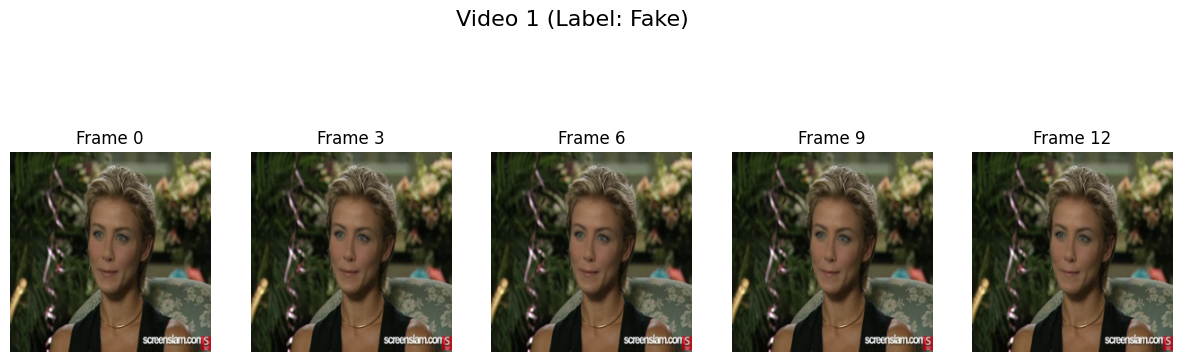

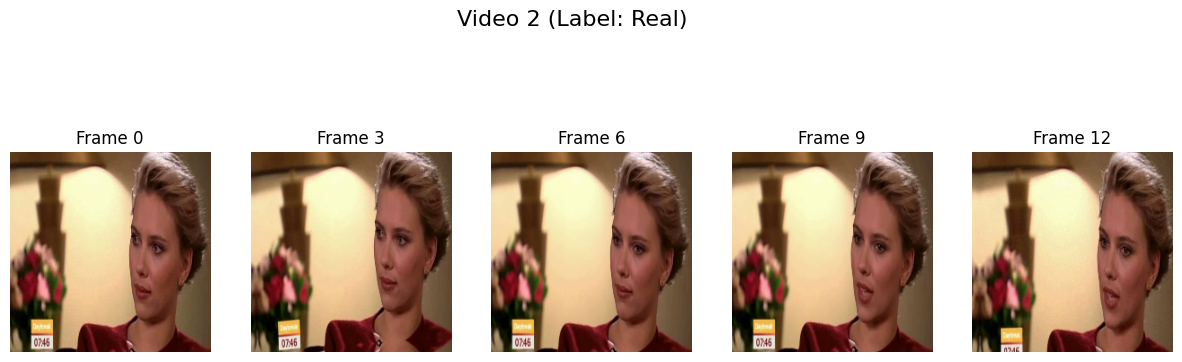

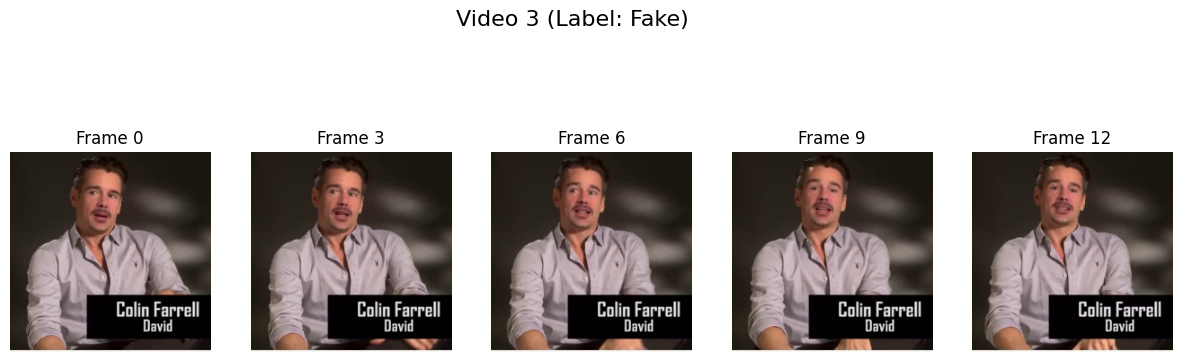

In [ ]:
# ===== Data Visualisation =====
def visualize_frames(data_loader, num_videos=2, num_frames=5):

    # Fetch one batch of data
    batch = next(iter(data_loader))
    videos, labels = batch  # videos: [batch_size, sequence_length, C, H, W], labels: [batch_size]

    videos = videos[:num_videos]  # Take the first few videos
    labels = labels[:num_videos]

    for i, video in enumerate(videos):
        # Convert video tensor to numpy array and move channel to the last dimension
        video = video.permute(0, 2, 3, 1).numpy()

        # Plot frames
        fig, axs = plt.subplots(1, num_frames, figsize=(15, 5))
        fig.suptitle(f"Video {i + 1} (Label: {'Fake' if labels[i] == 1 else 'Real'})", fontsize=16)

        for j in range(num_frames):
            frame_idx = int(j * (len(video) / num_frames))
            axs[j].imshow(video[frame_idx])
            axs[j].axis('off')
            axs[j].set_title(f"Frame {frame_idx}")

        plt.show()


visualize_frames(train_loader, num_videos=3, num_frames=5)


In [ ]:
# ===== Model Definition =====
class ResNeXtLSTM(nn.Module):
    def __init__(self, hidden_size=256, num_layers=1, num_classes=2):
        super().__init__()
        # Pretrained ResNeXt for feature extraction
        self.cnn = resnext50_32x4d(pretrained=True)
        # remove final classifier
        self.cnn.fc = nn.Identity()
        self.feature_dim = 2048  # resnext50_32x4d final feature size

        # LSTM over frame features
        self.lstm = nn.LSTM(self.feature_dim, hidden_size,
                            num_layers, batch_first=True, bidirectional=True)
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)
        feats = self.cnn(x)
        feats = feats.view(B, T, self.feature_dim)
        lstm_out, _ = self.lstm(feats)
        final = lstm_out[:, -1, :]
        return self.classifier(final)

model = ResNeXtLSTM().to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt50_32X4D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt50_32X4D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-7cdf4587.pth
100%|██████████| 95.8M/95.8M [00:00<00:00, 183MB/s]


In [ ]:
# ===== Loss, Optimizer & Training Loop =====
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def train_epoch(loader):
    model.train()
    total_loss, total_correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        preds = model(x)
        loss = criterion(preds, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (preds.argmax(1)==y).sum().item()

    return total_loss/len(loader.dataset), total_correct/len(loader.dataset)

def eval_epoch(loader):
    model.eval()
    total_loss, total_correct = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            loss = criterion(preds, y)
            total_loss += loss.item() * x.size(0)
            total_correct += (preds.argmax(1)==y).sum().item()
    return total_loss/len(loader.dataset), total_correct/len(loader.dataset)

best_val_acc = 0
for epoch in range(1, 21):
    print(f"\n--- Starting Epoch {epoch} ---")
    tr_loss, tr_acc = train_epoch(train_loader)
    val_loss, val_acc = eval_epoch(val_loader)
    print(f"Epoch {epoch:02} | Train: {tr_loss:.4f}/{tr_acc:.3f} | "
          f"Val: {val_loss:.4f}/{val_acc:.3f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")



--- Starting Epoch 1 ---
Epoch 01 | Train: 0.5732/0.704 | Val: 0.4882/0.796

--- Starting Epoch 2 ---
Epoch 02 | Train: 0.3482/0.853 | Val: 0.3735/0.847

--- Starting Epoch 3 ---
Epoch 03 | Train: 0.2304/0.910 | Val: 0.3264/0.877

--- Starting Epoch 4 ---
Epoch 04 | Train: 0.1719/0.936 | Val: 0.1382/0.946

--- Starting Epoch 5 ---
Epoch 05 | Train: 0.1428/0.947 | Val: 0.3222/0.878

--- Starting Epoch 6 ---
Epoch 06 | Train: 0.1224/0.950 | Val: 0.7488/0.725

--- Starting Epoch 7 ---
Epoch 07 | Train: 0.1006/0.964 | Val: 0.1268/0.959

--- Starting Epoch 8 ---
Epoch 08 | Train: 0.1027/0.966 | Val: 0.1509/0.949

--- Starting Epoch 9 ---
Epoch 09 | Train: 0.0714/0.976 | Val: 0.1403/0.959

--- Starting Epoch 10 ---
Epoch 10 | Train: 0.0738/0.975 | Val: 0.1830/0.949

--- Starting Epoch 11 ---
Epoch 11 | Train: 0.0767/0.976 | Val: 0.4385/0.837

--- Starting Epoch 12 ---
Epoch 12 | Train: 0.0591/0.979 | Val: 0.2089/0.950

--- Starting Epoch 13 ---
Epoch 13 | Train: 0.0574/0.981 | Val: 0.1855/0

In [ ]:
def compute_auc_eer(y_true, y_scores):
    auc = roc_auc_score(y_true, y_scores)
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    eer_threshold = thresholds[np.nanargmin(np.abs(fnr - fpr))]
    eer = fpr[np.nanargmin(np.abs(fnr - fpr))]
    return auc, eer, eer_threshold

In [ ]:
# ===== Test Set Evaluation =====
model.load_state_dict(torch.load("best_model.pth"))
test_loss, test_acc = eval_epoch(test_loader)
print(f"Test performance → Loss: {test_loss:.4f}, Acc: {test_acc:.3f}")

# Gather all predictions and ground‐truths
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        preds  = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Compute and print
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=["fake", "real"],
    digits=4
))

/tmp/ipykernel_19/395862751.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


Test performance → Loss: 0.1366, Acc: 0.967
Confusion Matrix:
[[700   5]
 [ 21  53]]

Classification Report:
              precision    recall  f1-score   support

        fake     0.9709    0.9929    0.9818       705
        real     0.9138    0.7162    0.8030        74

    accuracy                         0.9666       779
   macro avg     0.9423    0.8546    0.8924       779
weighted avg     0.9655    0.9666    0.9648       779



In [ ]:
def metrics_from_cm(cm):

    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp

    accuracy    = (tp + tn) / total
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1_score": f1,
        "support_negative": tn + fp,
        "support_positive": fn + tp
    }

metrics = metrics_from_cm(cm)
for k, v in metrics.items():
    print(f"{k:15s}: {v:.4f}" if isinstance(v, float) else f"{k:15s}: {v}")


true_negative  : 694
false_positive : 11
false_negative : 15
true_positive  : 59
accuracy       : 0.9666
precision      : 0.8429
recall         : 0.7973
specificity    : 0.9844
f1_score       : 0.8194
support_negative: 705
support_positive: 74


In [ ]:
# Gather logits and labels
model.eval()
all_logits = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        all_logits.extend(logits[:, 1].cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Compute AUC and EER
auc, eer, threshold = compute_auc_eer(all_labels, all_logits)
print(f"AUC: {auc:.4f}")
print(f"EER: {eer:.4f} at threshold {threshold:.4f}")


AUC: 0.9764
EER: 0.0936 at threshold -2.2784
